In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv('/archive.zip')

print(df.head())
print(df.info())

    show_id     type                                    title  \
0  81145628    Movie  Norm of the North: King Sized Adventure   
1  80117401    Movie               Jandino: Whatever it Takes   
2  70234439  TV Show                       Transformers Prime   
3  80058654  TV Show         Transformers: Robots in Disguise   
4  80125979    Movie                             #realityhigh   

                   director  \
0  Richard Finn, Tim Maltby   
1                       NaN   
2                       NaN   
3                       NaN   
4          Fernando Lebrija   

                                                cast  \
0  Alan Marriott, Andrew Toth, Brian Dobson, Cole...   
1                                   Jandino Asporaat   
2  Peter Cullen, Sumalee Montano, Frank Welker, J...   
3  Will Friedle, Darren Criss, Constance Zimmer, ...   
4  Nesta Cooper, Kate Walsh, John Michael Higgins...   

                                    country         date_added  release_year  \
0  Un

In [3]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64


In [6]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [7]:
le = LabelEncoder()

categorical_columns = [
    'director',
    'cast',
    'country',
    'rating',
    'duration',
    'listed_in'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [8]:
df['target'] = np.where(df['type'] == 'Movie', 1, 0)

In [9]:
X = df[
    [
        'release_year',
        'director',
        'country',
        'rating',
        'duration',
        'listed_in'
    ]
]

y = df['target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [12]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [13]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [14]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8829190056134724
Decision Tree Accuracy: 0.9903769045709703
Random Forest Accuracy: 0.9951884522854851


In [15]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       415
           1       0.99      1.00      1.00       832

    accuracy                           1.00      1247
   macro avg       1.00      0.99      0.99      1247
weighted avg       1.00      1.00      1.00      1247



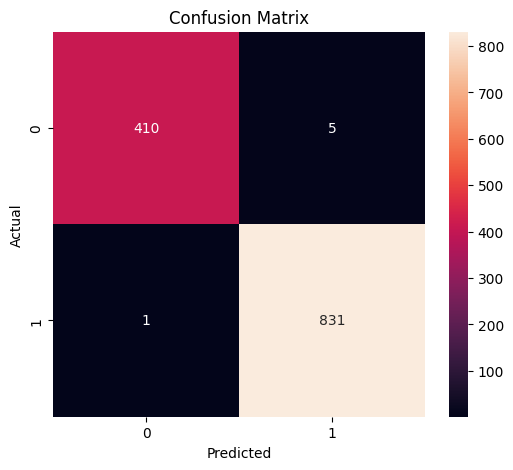

In [16]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

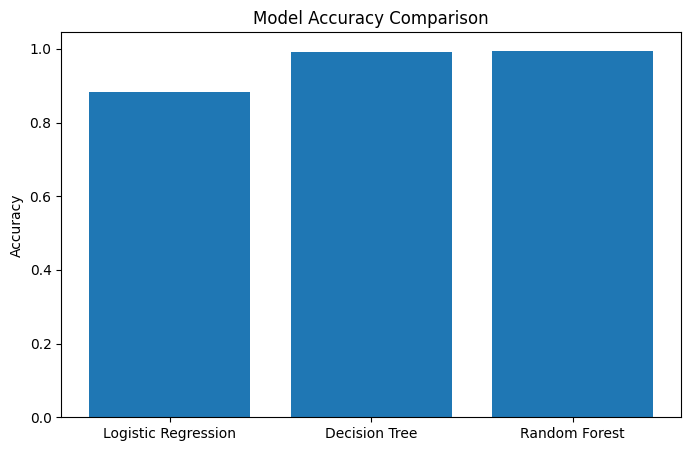

In [17]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

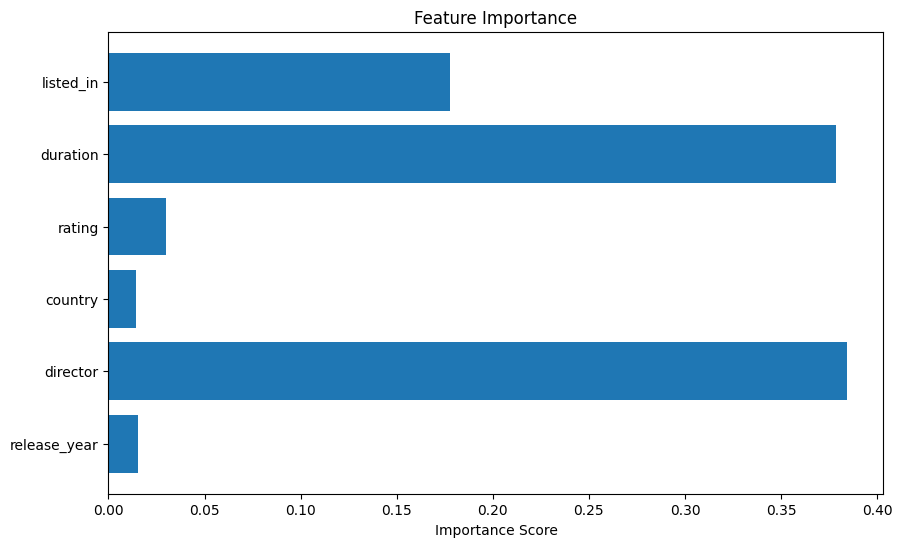

In [18]:
importance = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features, importance)

plt.title('Feature Importance')
plt.xlabel('Importance Score')

plt.show()

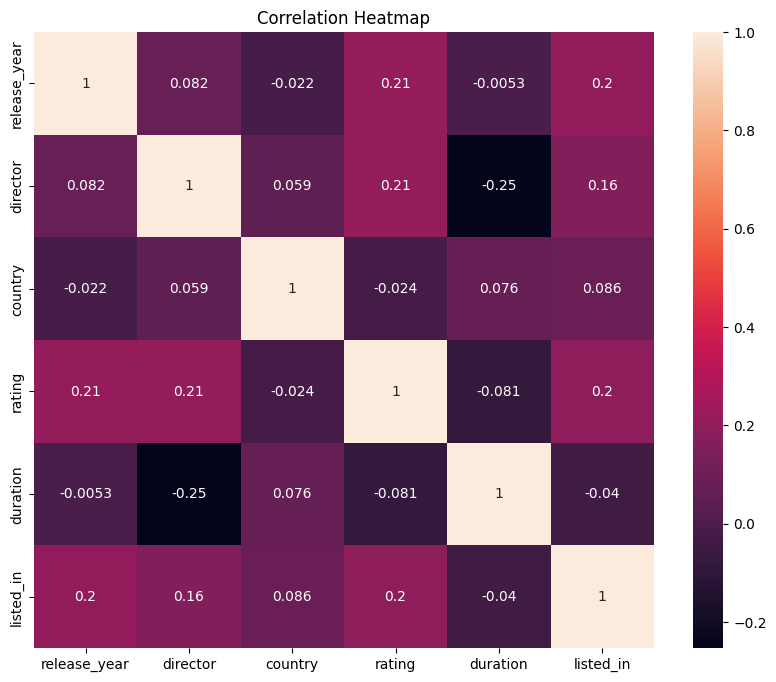

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(X.corr(), annot=True)

plt.title('Correlation Heatmap')

plt.show()

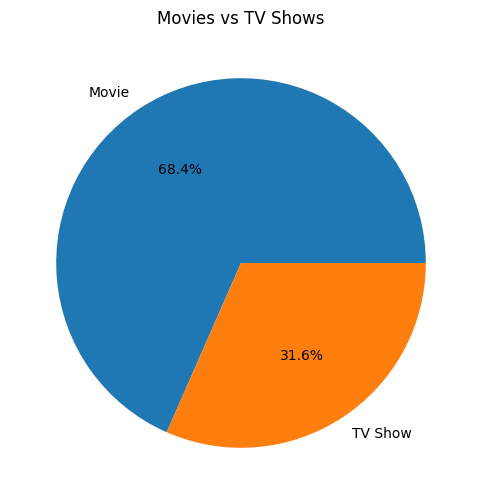

In [20]:
content_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    content_counts,
    labels=content_counts.index,
    autopct='%1.1f%%'
)

plt.title('Movies vs TV Shows')

plt.show()

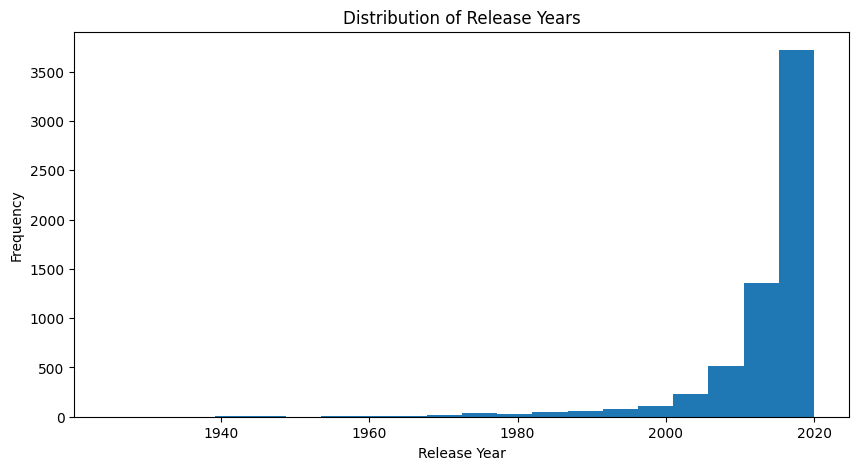

In [21]:
plt.figure(figsize=(10,5))

plt.hist(df['release_year'], bins=20)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()